# ANÁLIISIS PARA UNA PREDICCIÓN DEL MODELO

Se presentan los códigos desarrollados de manera organizada, comprensible y concisa, importando las funciones desarrolladas en los Notebooks anteriores, las que fueron implementadas como paquetes en archivos `xai_utils/*.py`.


In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

# Add module tsmule to syspath
print("Current working dir:", os.getcwd())
sys.path.insert(0, 'METHODS/ts-mule')

# Filter out all RuntimeWarning
warnings.filterwarnings("ignore", category=RuntimeWarning) 

import logging 
logging.getLogger("stumpy").setLevel(logging.ERROR)

Current working dir: C:\Users\asuso\Documents\UTFSM\Doctorado Ing Aplicada\Cursos\INF473 - Introducción XAI\Proyecto\repo


In [2]:
# Add module tsmule to system path
from tsmule.xai.lime import LimeTS
from tsmule.xai.evaluation import PerturbationAnalysis
from tsmule.sampling.segment import MatrixProfileSegmentation, SAXSegmentation
from tsmule.xai.viz import visualize_segmentation_mask

In [3]:
# Funciones desarrolladas para implementar ts-MULE en el set de datos
from xai_utils.tsmule_analysis import analyze_with_tsmule
from xai_utils.tsmule_plots import plot_relevance_map, plot_original_vs_perturbed, plot_relevance_per_feature, plot_relevance_summary

In [4]:
#Cargar datos
def load_pickle(p_name):
    with open(p_name, 'rb') as file:
        # Load the data from the file
        data = pickle.load(file)
    return data

data_path = 'DATA\\'
X_test = load_pickle(data_path+'xtest_new.pickle')


In [5]:
#Cargar modelo
import keras
from keras.models import load_model

model = load_model('MODELS\\transfer_learned_tsunami_classifier.keras')

C:\Users\asuso\anaconda3\envs\XAI2026_proj_v2\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [6]:
# Seleccionar muestra de los datos de test
m = 1
x_nuevo = X_test[m:m+1]  # serie de tsunami a evaluar
X_nuevo = X_test[m]
n_steps, features = X_nuevo.shape
model.predict(x_nuevo)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step


array([[0.99999976]], dtype=float32)

In [7]:
resultados = analyze_with_tsmule(
    model=model,
    x=X_nuevo,
    n_runs=1,
    n_samples=50,
    segmentation_method='slopes-sorted',
    feature_names=['Boya 1', 'Boya 2', 'Boya 3', 'Boya 4', 'Boya 5', 'Boya 6'],
    save_path='RESULTADOS_TSMULE\\'
)

# Acceder a los resultados
relevance = resultados['relevance_promedio']
x_pert = resultados['x_perturbed']

Calculando relevancia con 1 iteraciones...
  Inicio: 21:45:17
¡Cálculo completado! Fin: 21:46:44
Resultados guardados en: RESULTADOS_TSMULE\_*.npy


C:\Users\asuso\anaconda3\envs\XAI2026_proj_v2\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.354e-04, tolerance: 5.154e-04
  model = cd_fast.enet_coordinate_descent(


Figura guardada: RESULTADOS_TSMULE\_mapa_relevancia.pdf


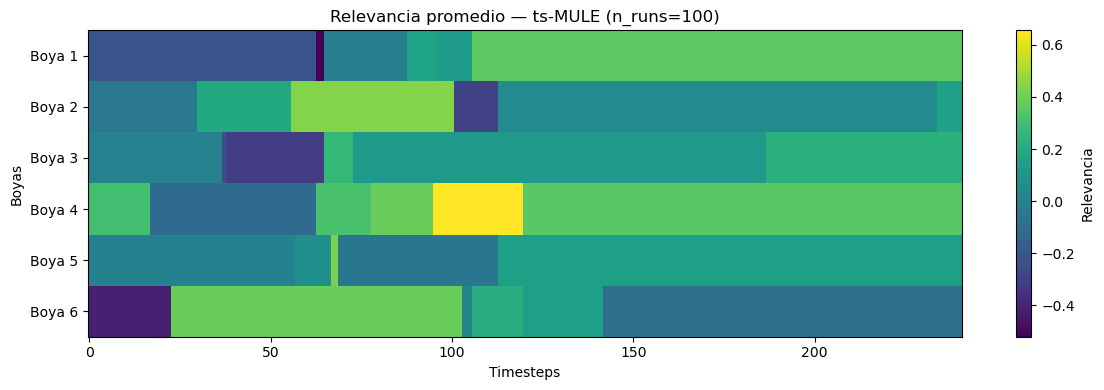

Figura guardada: RESULTADOS_TSMULE\_series_perturbadas.pdf


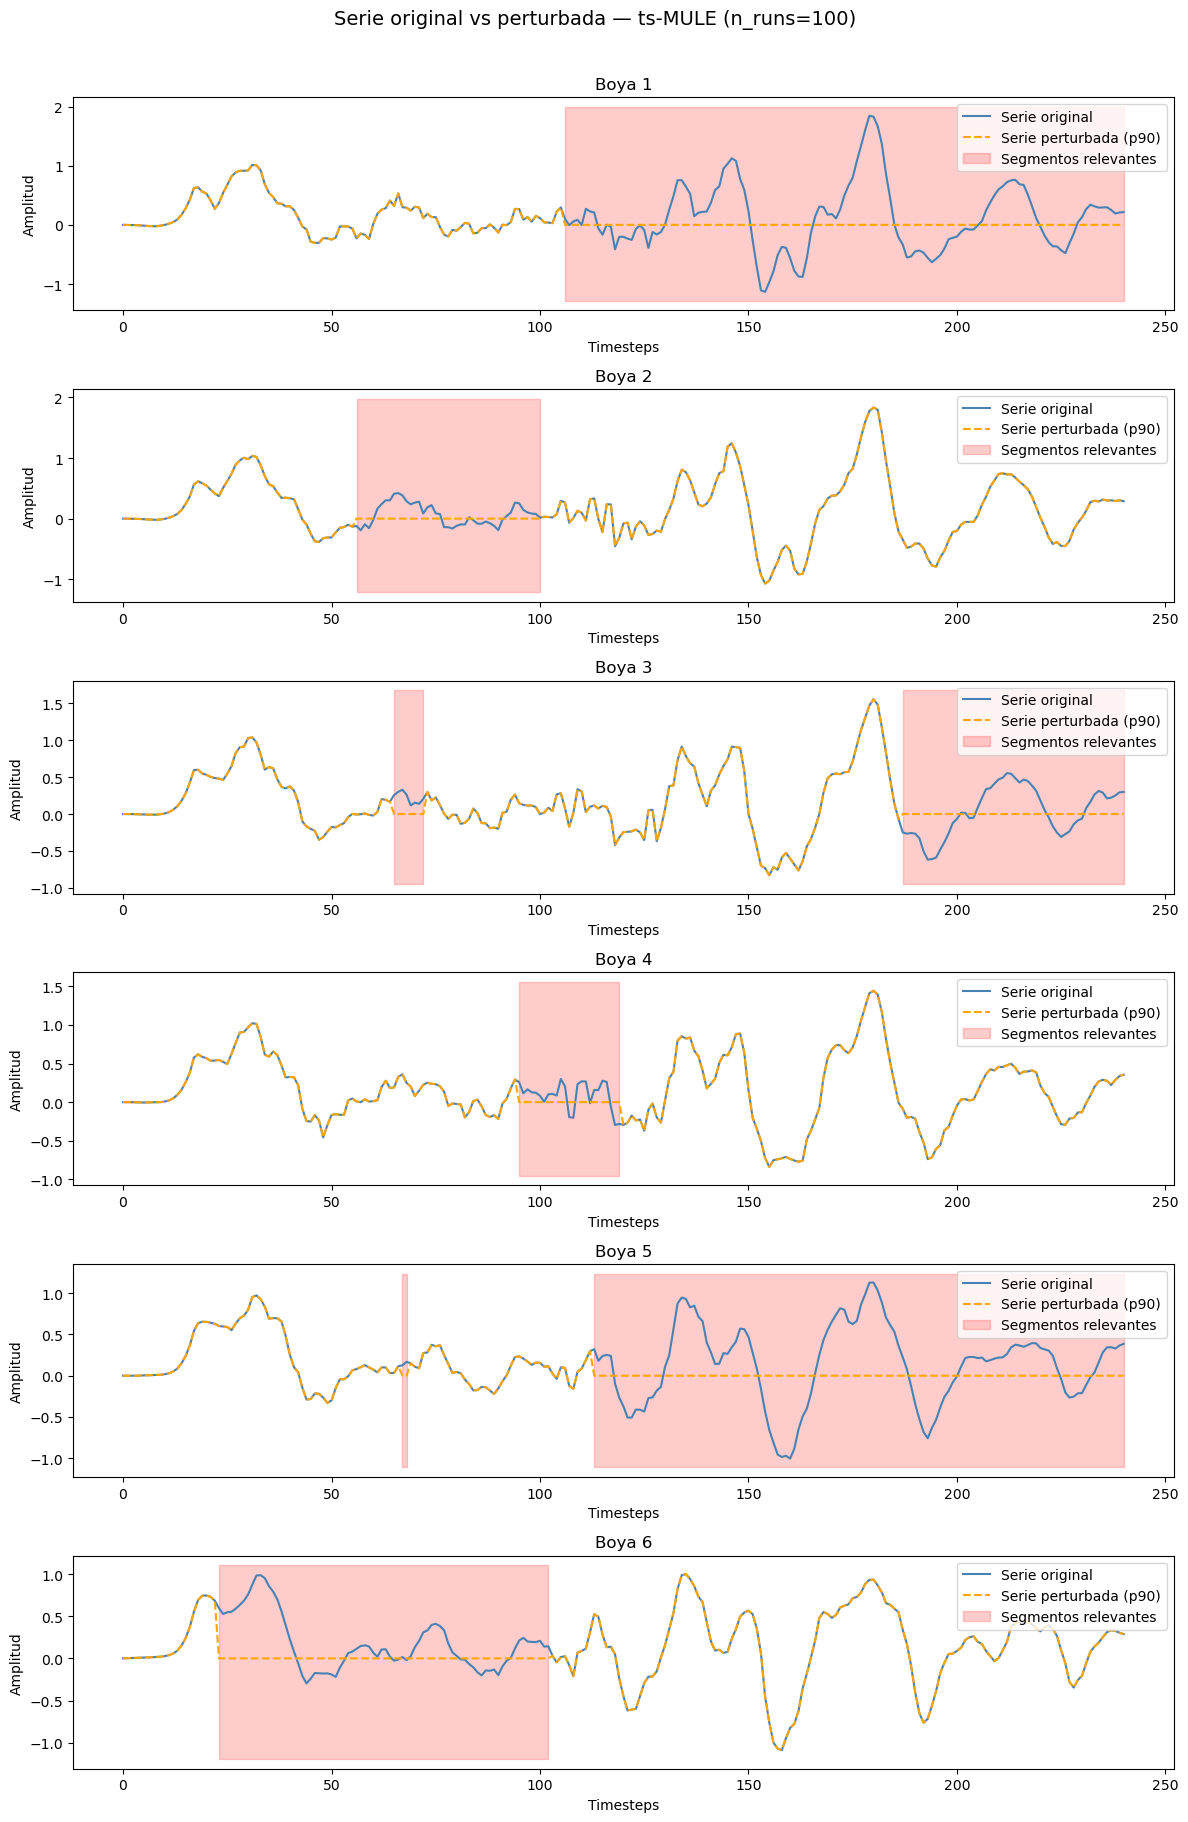

Figura guardada: RESULTADOS_TSMULE\_relevancia_por_boya.pdf


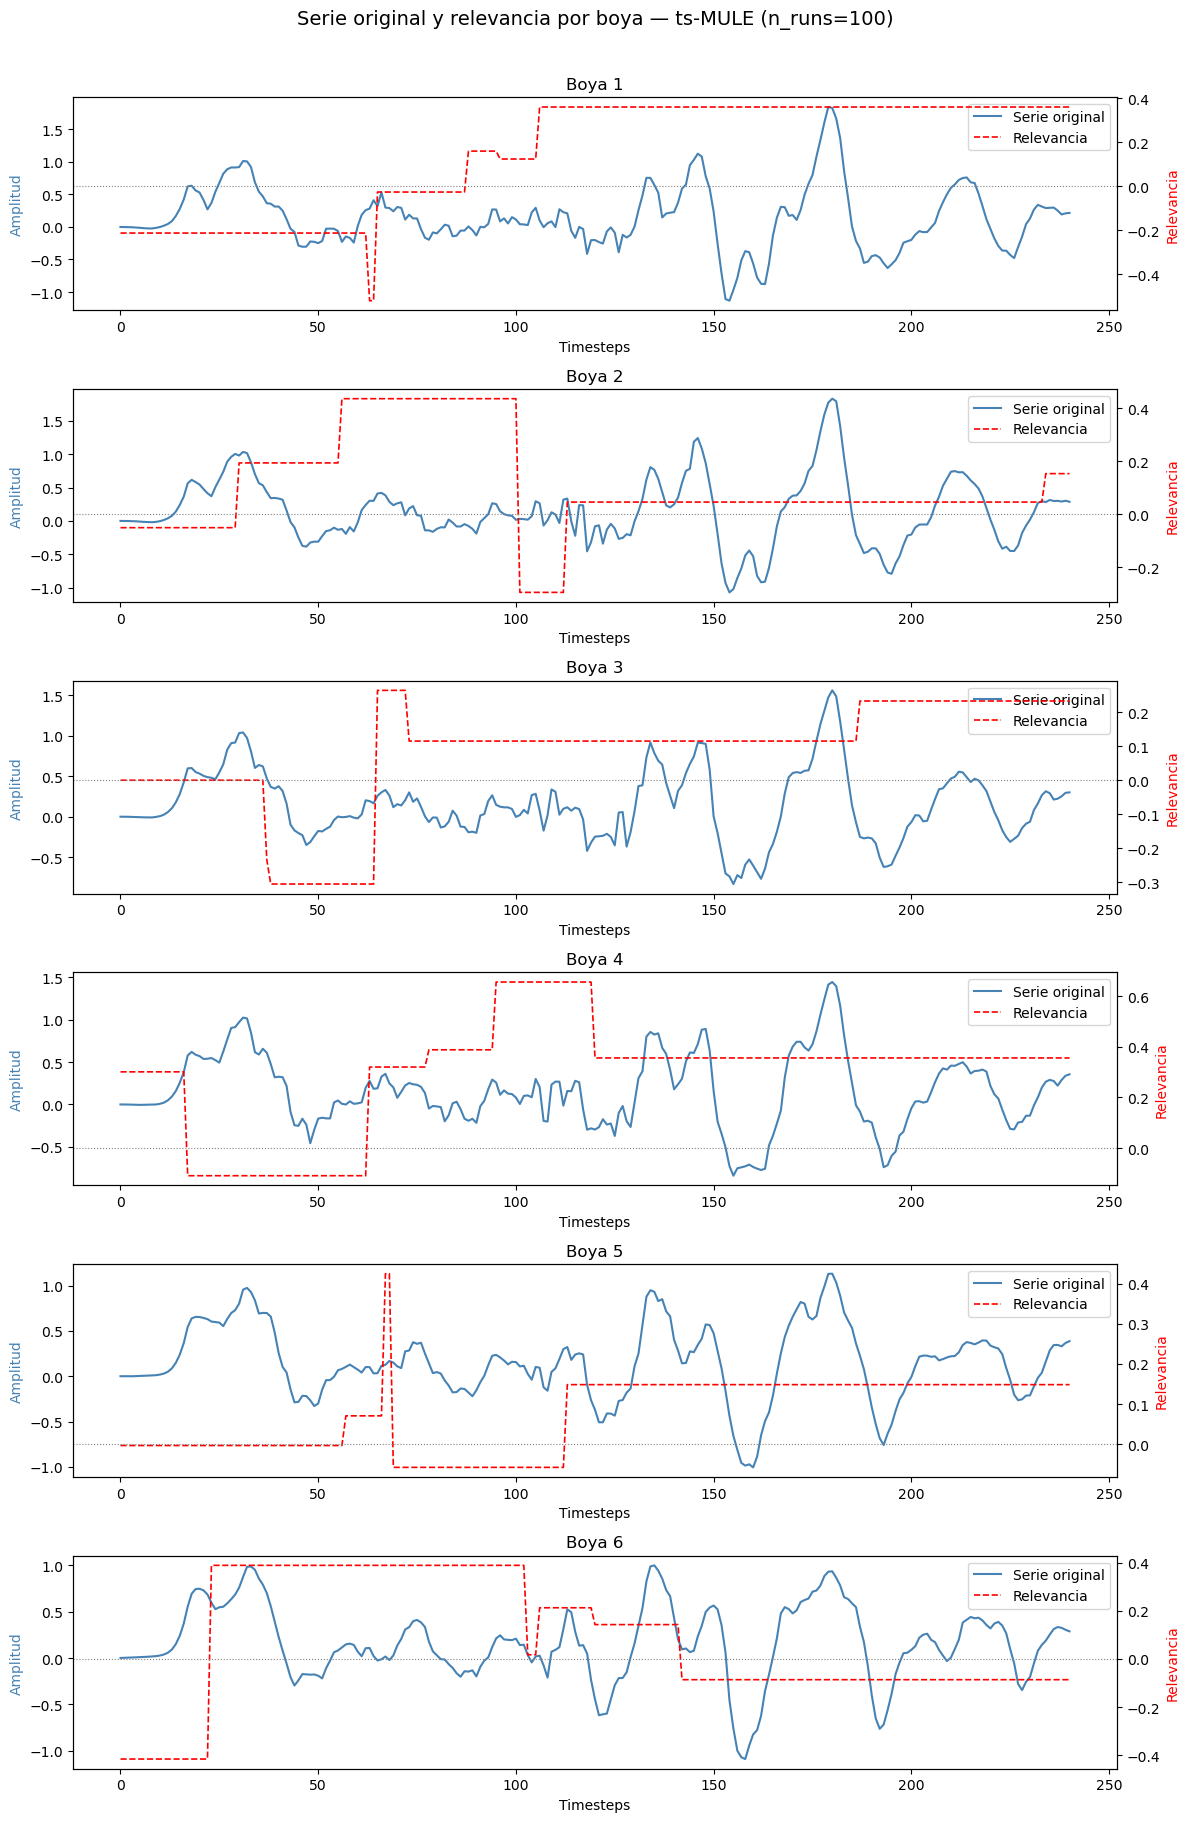

Figura guardada: RESULTADOS_TSMULE\_resumen_relevancia.pdf


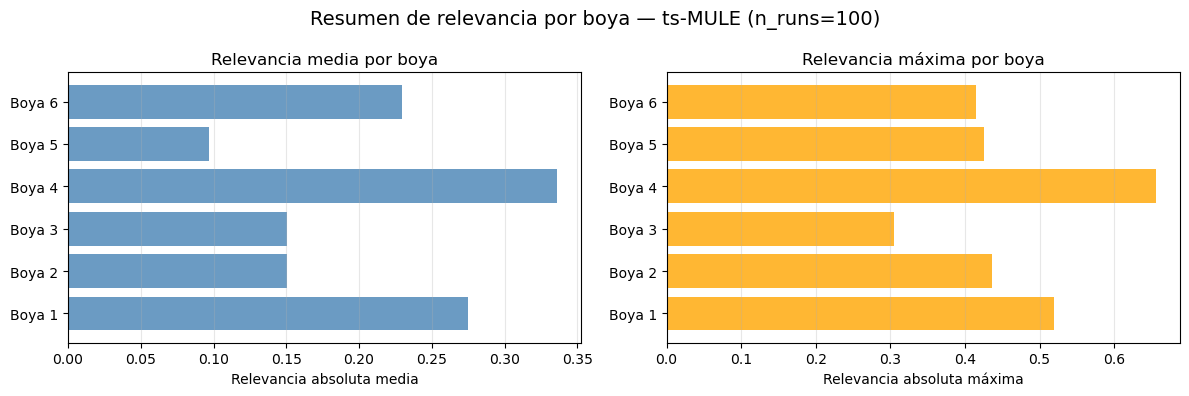

In [8]:
feature_names = ['Boya 1', 'Boya 2', 'Boya 3', 'Boya 4', 'Boya 5', 'Boya 6']
save_path = 'RESULTADOS_TSMULE\\'

plot_relevance_map(resultados, feature_names=feature_names, n_runs=100,
                   save_path=save_path)

plot_original_vs_perturbed(resultados, feature_names=feature_names, n_runs=100,
                            percentile=90, save_path=save_path)

plot_relevance_per_feature(resultados, feature_names=feature_names, n_runs=100,
                            save_path=save_path)

plot_relevance_summary(resultados, feature_names=feature_names, n_runs=100,
                       save_path=save_path)